In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset load karein
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Train data ki pehli 5 rows dekhein
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Dataset ka shape aur info check karein
print("Train Shape:", train_df.shape)
print("\n--- Missing Values in Train Data ---")
print(train_df.isnull().sum())

Train Shape: (891, 12)

--- Missing Values in Train Data ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# Age ko median se aur Embarked ko mode se fill karein
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)

# Cabin column mein bohot zyada missing values hain, isay drop kar sakte hain ya nayi category bana sakte hain
train_df.drop(columns=['Cabin'], inplace=True)

print("Missing values after cleaning:")
print(train_df.isnull().sum())

Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13604\3829105244.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13604\3829105244.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

In [4]:
# 1. FamilySize (SibSp + Parch + 1)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

# 2. Title Extraction (Name se title nikalna jaise Mr, Mrs)
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Check karein ke naye features kaise bane hain
train_df[['Name', 'FamilySize', 'Title']].head()

<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13604\2738020221.py:5: SyntaxWarning: invalid escape sequence '\.'
  train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,Name,FamilySize,Title
0,"Braund, Mr. Owen Harris",2,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,Mrs
2,"Heikkinen, Miss. Laina",1,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,Mrs
4,"Allen, Mr. William Henry",1,Mr


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13604\3493205579.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='Pclass', y='Fare', palette='Set3')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13604\3493205579.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='FamilySize', y='Survived', palette='Blues')


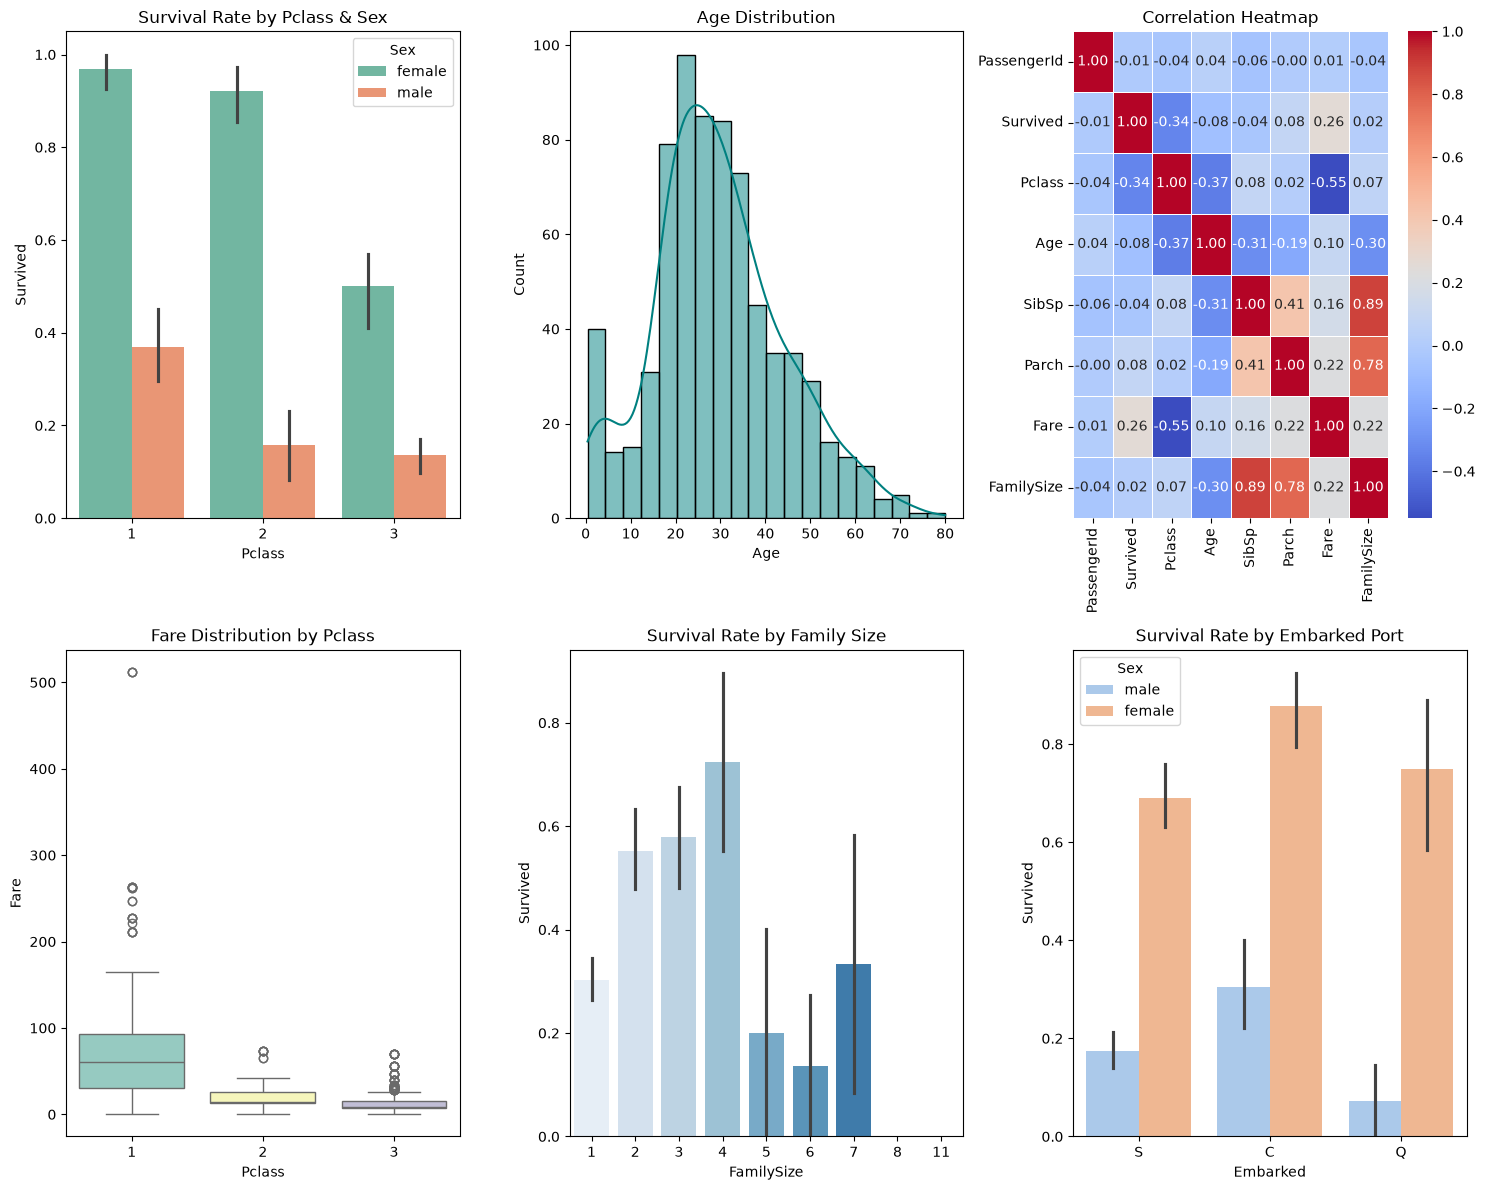

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure size set karein
plt.figure(figsize=(15, 12))

# 1. Survival Rate by Sex and Pclass
plt.subplot(2, 3, 1)
sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex', palette='Set2')
plt.title('Survival Rate by Pclass & Sex')

# 2. Age Distribution
plt.subplot(2, 3, 2)
sns.histplot(train_df['Age'].dropna(), kde=True, color='teal')
plt.title('Age Distribution')

# 3. Correlation Heatmap (Numerical features)
plt.subplot(2, 3, 3)
numeric_cols = train_df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')

# 4. Fare Distribution across Pclass
plt.subplot(2, 3, 4)
sns.boxplot(data=train_df, x='Pclass', y='Fare', palette='Set3')
plt.title('Fare Distribution by Pclass')

# 5. FamilySize vs Survival Rate
plt.subplot(2, 3, 5)
sns.barplot(data=train_df, x='FamilySize', y='Survived', palette='Blues')
plt.title('Survival Rate by Family Size')

# 6. Embarked Port vs Survival
plt.subplot(2, 3, 6)
sns.barplot(data=train_df, x='Embarked', y='Survived', hue='Sex', palette='pastel')
plt.title('Survival Rate by Embarked Port')

plt.tight_layout()
plt.show()

### **Key Data-Driven Insights**
* **Gender Disparity in Survival:** Female passengers had a significantly higher survival rate (~74%) compared to male passengers (~19%), directly reflecting the "women and children first" evacuation protocol.
* **Socio-Economic Impact (Pclass):** First-class passengers enjoyed a much higher survival probability than third-class passengers, highlighting how socio-economic status and cabin location affected access to lifeboats.
* **Age & Vulnerability:** Children and younger passengers had better survival outcomes compared to older adults, as priority was given to dependents during rescue operations.
* **Family Size Dynamics:** Passengers traveling with small to moderate families (Family Size of 2 to 4) had higher survival rates than solo travelers or those from very large families who faced logistical hurdles.
* **Embarkation Port Effect:** Passengers who boarded from Cherbourg (Port C) showed a higher overall survival rate, which correlates with a larger proportion of wealthy first-class ticket holders boarding from that location.

### **Stakeholder Follow-Up Questions**
1. *How did passenger cabin deck locations correlate with proximity to lifeboats and ultimate survival rates?*
2. *Which machine learning algorithms are best suited to predict passenger survival based on these engineered features, and what baseline accuracy can we expect?*